### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd
from wordcloud import WordCloud

### Loading Dataset

In [2]:
data_path = Path('data/raw/fake_job_postings.csv')
df_source = pd.read_csv(data_path)
df = df_source.copy(deep=True)

print(df.shape)
print(df.info())
print(df.describe())
print(df.columns.tolist())


(17880, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  obje

The dataset has 17,880 rows and 18 columns.

The columns are job_id, title, location, department, salary_range, company_profile, description, requirements, benefits, telecommuting, has_company_logo, has_questions, employment_type, required_experience, required_education, industry, function, fraudulent.

There are 5 numerical int64 columns (job_id, telecommuting, has_company_logo, has_questions, fraudulent), while the rest are text str columns.

### Data Cleaning

This section serves to clean the dataset by handling inconsistencies in strings, null or empty values, etc.


In [3]:
df.isnull().sum().sort_values(ascending=False)


salary_range           15012
department             11547
required_education      8105
benefits                7212
required_experience     7050
function                6455
industry                4903
employment_type         3471
company_profile         3308
requirements            2696
location                 346
description                1
job_id                     0
telecommuting              0
has_questions              0
has_company_logo           0
title                      0
fraudulent                 0
dtype: int64

In [4]:
df.isnull().mean() * 100

job_id                  0.000000
title                   0.000000
location                1.935123
department             64.580537
salary_range           83.959732
company_profile        18.501119
description             0.005593
requirements           15.078300
benefits               40.335570
telecommuting           0.000000
has_company_logo        0.000000
has_questions           0.000000
employment_type        19.412752
required_experience    39.429530
required_education     45.329978
industry               27.421700
function               36.101790
fraudulent              0.000000
dtype: float64

Given that salary range has 84.0% missing values and department has 64.5% missing values, can consider dropping these features since they are too sparse to extract meaning.
Perhaps can transform salary_range to salary_provided boolean column instead.

In [5]:
placeholders = ['n/a', 'na', 'none', 'null', '-', '?', 'not specified', 'unknown', 'other']
for col in df.select_dtypes(include='object').columns:
    mask = df[col].str.strip().str.lower().isin(placeholders)
    count = mask.sum()
    if count > 0:
        print(f"column name({col}): {count} placeholder values")
        print(df[col][mask].value_counts())
        print('\n')

column name(department): 2 placeholder values
department
Unknown    1
Other      1
Name: count, dtype: int64


column name(benefits): 1 placeholder values
benefits
na    1
Name: count, dtype: int64


column name(employment_type): 227 placeholder values
employment_type
Other    227
Name: count, dtype: int64


column name(function): 325 placeholder values
function
Other    325
Name: count, dtype: int64




In [6]:
df['benefits'] = df['benefits'].replace('na', np.nan)
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
str_cols =  ['title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']
num_cols = ['job_id', 'telecommuting', 'has_company_logo', 'has_questions', 'fraudulent']
text_cols = ['company_profile', 'description', 'requirements', 'benefits']
cat_cols = ['location', 'employment_type', 'required_experience', 
            'required_education', 'industry', 'function']
binary_cols = ['telecommuting', 'has_company_logo', 'has_questions']
target = 'fraudulent'
to_drop = ['job_id', 'department', 'salary_range']

df[text_cols] = df[text_cols].fillna('')
df[cat_cols] = df[cat_cols].fillna('Not Provided')

df.isnull().sum()

job_id                     0
title                      0
location                   0
department             11553
salary_range           15012
company_profile            0
description                0
requirements               0
benefits                   0
telecommuting              0
has_company_logo           0
has_questions              0
employment_type            0
required_experience        0
required_education         0
industry                   0
function                   0
fraudulent                 0
dtype: int64

We will drop job_id column as ids do not have any predictice power over whether selected job is fradulent

In [7]:
df = df.drop(['job_id'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                17880 non-null  object
 1   location             17880 non-null  object
 2   department           6327 non-null   object
 3   salary_range         2868 non-null   object
 4   company_profile      17880 non-null  object
 5   description          17880 non-null  object
 6   requirements         17880 non-null  object
 7   benefits             17880 non-null  object
 8   telecommuting        17880 non-null  int64 
 9   has_company_logo     17880 non-null  int64 
 10  has_questions        17880 non-null  int64 
 11  employment_type      17880 non-null  object
 12  required_experience  17880 non-null  object
 13  required_education   17880 non-null  object
 14  industry             17880 non-null  object
 15  function             17880 non-null  object
 16  frau

given that the location column can be split into `country`, `state`, `city`, We will create 3 additional columns country, state and city.

In [ ]:
df['location'].head()
df[["country","state","city"]] = df["location"].str.split(",", n=2, expand=True)

#top 5 countries
df["country"].value_counts().head(5)

440

we count the number of values with missing states or cities.

In [30]:
df[["state", "city"]].isna().sum()

state    440
city     440
dtype: int64

### Exploratory Data Analysis (EDA)

This section serves to conduct exploratory data analysis on the dataset.

#### Univariate analysis

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
telecommuting,17880.0,0.042897,0.202631,0.0,0.0,0.0,0.0,1.0
has_company_logo,17880.0,0.795302,0.403492,0.0,1.0,1.0,1.0,1.0
has_questions,17880.0,0.491723,0.499945,0.0,0.0,0.0,1.0,1.0
fraudulent,17880.0,0.048434,0.214688,0.0,0.0,0.0,0.0,1.0


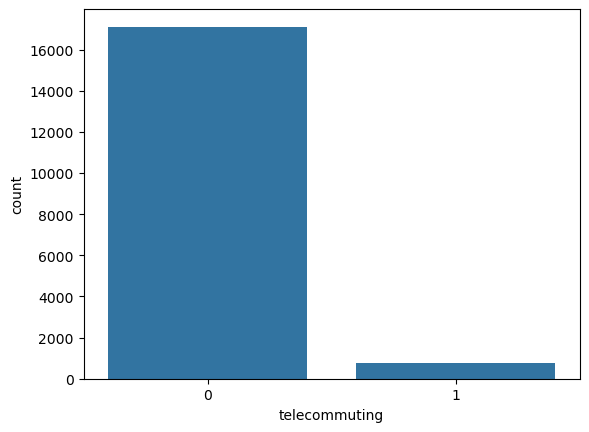

In [ ]:
sns.countplot(x=df['telecommuting'])
plt.show()

we can see that most jobs do not involve telecommunting

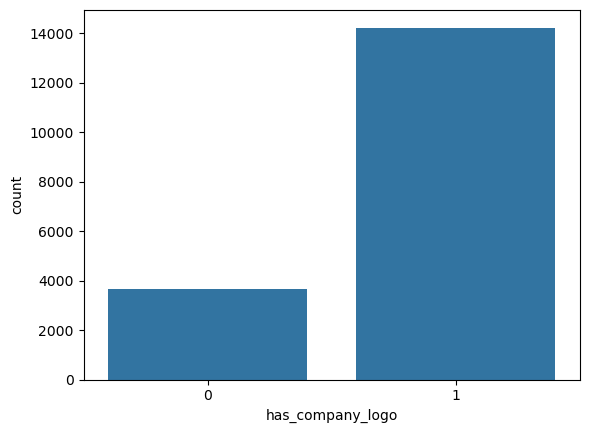

In [ ]:
sns.countplot(x=df['has_company_logo'])
plt.show()

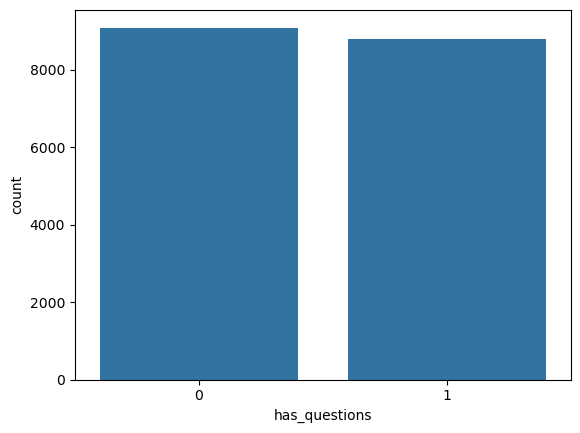

In [ ]:
sns.countplot(x=df['has_questions'])
plt.show()

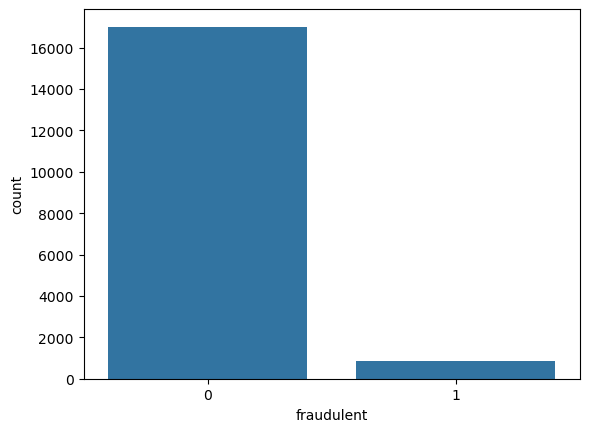

In [ ]:
sns.countplot(x=df['fraudulent'])
plt.show()

majority of all jobs are not fradulent

We used a word cloud to identify some of the common job titles posted. possibly can split into part time vs full time via - deliminator?

In [ ]:
df['title'].head(10)

0                             Marketing Intern
1    Customer Service - Cloud Video Production
2      Commissioning Machinery Assistant (CMA)
3            Account Executive - Washington DC
4                          Bill Review Manager
5                             Accounting Clerk
6                        Head of Content (m/f)
7             Lead Guest Service Specialist   
8                                   HP BSM SME
9      Customer Service Associate - Part Time 
Name: title, dtype: object

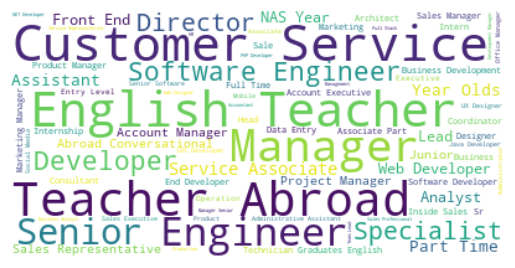

In [ ]:
df['title'].head()
text = " ".join(title for title in df.title)
wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(text)
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

### Feature Engineering 

This section serves to engineer new features to discover relationships through the interactions between features.